# Prototyping Difference Gradient Analysis for MISalign 2.0

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [10]:
%matplotlib inline

In [15]:
from misalign.model.project import MISProjectJSON
from misalign.alignment.difference_gradient import difference_gradient_analysis,\
    metric_squared_mean,\
    metric_absolute_mean


In [4]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [5]:
mis_project.get_relations()[1].get_relation("r")

(8, -1141)

(np.int64(9), np.int64(-1087))


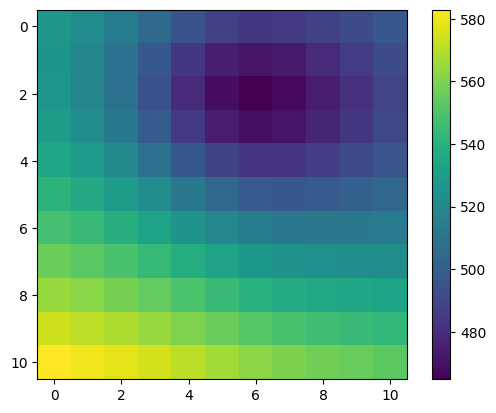

In [17]:
selected_relation=mis_project.get_relations()[0]
dga_results=difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy="full_grid",
        strategy_max_size=5,
        metric=metric_squared_mean)
print(dga_results["optimized_offset"])
plt.figure()
plt.imshow(dga_results["grid_results"]) # Can use extent kwarg to adjust positioning.
plt.colorbar()